### Trajectory classification

This code calculates the main trajectory metrics and segments the trajectory into the different motility states of Didinium nasutum.
The output for all trajectories is used to compute the velocity density map and the survival probability of the three motility states in the codes: 'plotting_velocity_map.ipynb' and 'plotting_survival_probability.ipynb'.

**Input:**

*file_directory*: Path to folder containing the trajectory file. 

*file_name*: The name of the csv file with the trajectory points.

*px_mm*: The number of pixels equal to 1 mm

*fps*: The frame rate of the timelapse

**Output:**

*trajectory_metrics_[window size].csv*: A csv file with the linear and angular velocity of the cell in time, as well as the metrics DAV and MSD used in the classification

*states_thresh_msd_[msd value]_thresh_dav_[dav value].csv*: A csv file with the state id number per frame after classification of the full trajectory

*scatter_data_velocity_map.npz* : the numpy arrays with the velocity map data 

*time_statistics_thresh_msd_[msd value]_thresh_dav_[dav value].csv*:  A csv file with the segment durations for each state and the number of segments

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.signal import savgol_filter
from scipy.stats import circvar
from matplotlib.lines import Line2D

### Input

In [ ]:
### Definition of input and output path
file_directory = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name = "cell_01_track.csv"

### Definition of output path
output_path =  file_directory + "results\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

### Pixel size and framerate
px_mm = 67.5 
fps = 30


### Pre-processing

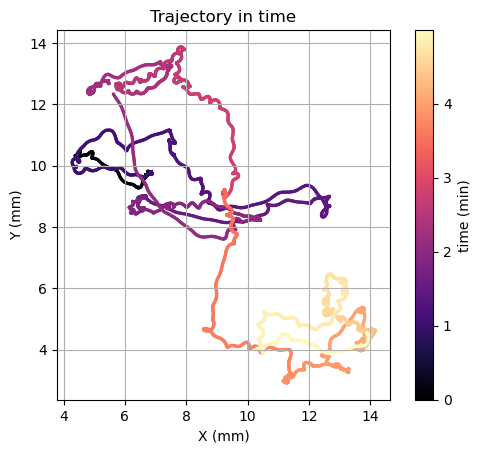

In [3]:
### Extracting the tracks:
file_path = file_directory + file_name
track_data = pd.read_csv(file_path)

x = track_data['x'] / px_mm
y = track_data['y'] / px_mm
time = track_data['frame'] /fps
time = time/60 # in min

plt.figure()
plt.scatter(x, y, c=time, cmap="magma", s=2)
plt.colorbar(label='time (min)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Trajectory in time')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()  


In [4]:
### Conversion to arrays
translation_x_array = x.to_numpy()
translation_y_array = y.to_numpy()
translations = np.column_stack((translation_x_array, translation_y_array))

time_in_sec = time *60
time_axis_sec_with_0 = time_in_sec.to_numpy()
time_steps = (np.diff(time_axis_sec_with_0).reshape(-1, 1)) 

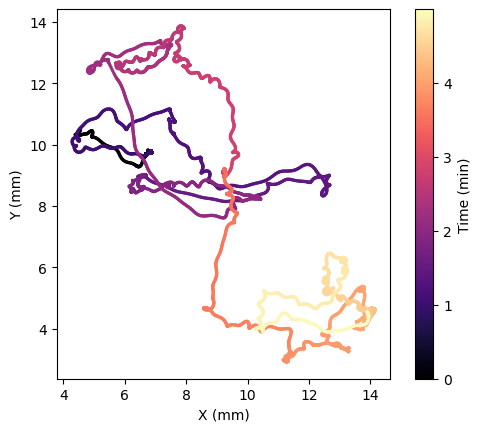

In [5]:
### Savitzky-Golay smoothing
target_window_smoothing = 1/2  # in sec!  
window_smoothing_SG = int(np.ceil(target_window_smoothing * fps))
window_smoothing_SG_odd = window_smoothing_SG if window_smoothing_SG % 2 != 0 else window_smoothing_SG + 1

noisy_signal_x = translations[:,0]   
noisy_signal_y = translations[:,1]

smoothed_x = savgol_filter(noisy_signal_x, window_smoothing_SG_odd, polyorder=2)
smoothed_y = savgol_filter(noisy_signal_y, window_smoothing_SG_odd, polyorder=2)

smoothed_translations = np.column_stack((smoothed_x, smoothed_y))

plt.figure()
plt.scatter(smoothed_x, smoothed_y, c=time, cmap="magma", s=2)
cbar = plt.colorbar(label='Time (min)')
cbar.set_label('Time (min)')  
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.grid(False)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

### Trajectory metrics

In [ ]:
### Istantaneous linear velocity:
translations_to_analyze = smoothed_translations  

velocities = []
velocities = np.diff(translations_to_analyze, axis = 0) / time_steps
speed_cell = np.linalg.norm(velocities, ord=2,  axis=1) 

### Instantaneous angles and reorientation:
dot_product = np.sum(velocities[:-1, :] * velocities[1:, :], axis=1)
norms_prev = np.linalg.norm(velocities[:-1, :], axis=1)
norms_next = np.linalg.norm(velocities[1:, :], axis=1)
denominator = np.clip(norms_prev * norms_next, a_min=1e-18, a_max=None)

cosine_of_consequetive_angle = dot_product / denominator
angles = np.arccos(np.clip(cosine_of_consequetive_angle, -1.0, 1.0))  # gives angle from 0 to π

# np.arccos gives angle from 0 to π. To keep the sign for the direction:
cross_product_z = (velocities[:-1, 0] * velocities[1:, 1] - 
                   velocities[:-1, 1] * velocities[1:, 0])

signed_angles_in_rad = np.where(cross_product_z >= 0, angles, -angles) 
signed_angles_in_deg = np.degrees(signed_angles_in_rad)

### Angular velocity:
ang_velocity = signed_angles_in_rad /  time_steps.flatten()[1:]


### State identification

In [7]:
### Smoothing with a rolling mean filter 
target_window_mov_av = 1 # in sec
window_size_mov_av = int(np.ceil(target_window_mov_av * fps))
window_size_mov_av_odd =  window_size_mov_av if window_size_mov_av % 2 != 0 else window_size_mov_av + 1

speed_series = pd.Series(speed_cell)
speed_cell_smooth = speed_series.rolling(window=window_size_mov_av_odd, center=True, min_periods=1).mean()

ang_velocity_series = pd.Series(ang_velocity)
ang_velocity_cell_smooth = ang_velocity_series.rolling(window=window_size_mov_av_odd, center=True, min_periods=1).mean()

In [8]:
### Calculating DAV
def compute_dav_for_window_size(trajectory, signed_angles_in_rad, window_size):
        current_trajectory = trajectory 
        variance_in_directionality = []

        for i in range(current_trajectory.shape[0]):
            start = max(0,  i - window_size//2)
            end = min(current_trajectory.shape[0], i + window_size//2)

            if start == 0:
                end = min(current_trajectory.shape[0], start + window_size) 
            elif end == current_trajectory.shape[0]:
                start = max(0, end - window_size)

            xy = current_trajectory[start:end, :] 

            variance_in_directionality.append(circvar(signed_angles_in_rad[start:end], high=np.pi, low=-np.pi))

        return np.asanyarray(variance_in_directionality)

target_window_features = 1  # in sec
window_features = int(np.ceil(target_window_features * fps))
window_features_odd = window_features if window_features % 2 != 0 else window_features + 1

dav_array  = compute_dav_for_window_size(translations_to_analyze, signed_angles_in_rad, window_features_odd)
dav_array = dav_array.reshape(1, -1)[0]



In [9]:
### Calculating MSD
def moving_window_MSD(time_series, window_size):
    msd_values = []
    for start in range(len(time_series) - window_size + 1):
        window = time_series[start:start + window_size]
        msd = np.mean((window[1:] - window[:-1])**2)
        msd_values.append(msd)
        
    return np.array(msd_values)

window_size = window_features_odd   
msd_values = moving_window_MSD(translations_to_analyze, window_size)
border_size = int((window_size-1)/2)

### Defining the thresholds

In [10]:
### Surface spinning (no net translation):
threshold_MSD = 1e-05
states_rot_before_padding = np.where(msd_values < threshold_MSD, 0, 1)
states_rot = np.concatenate([np.full(border_size, 1), states_rot_before_padding,np.full(border_size, 1)])

### Reorientations:
threshold_dav = 0.04
states_reor = np.where(dav_array < threshold_dav, 2, 1)

states_side = np.where((states_rot !=0)&(states_reor == 2), 2, 1)

states = states_side *states_rot

states_spinning_nan    =  np.where(states != 0, np.nan, states)
states_forward_nan     =  np.where(states != 2, np.nan, states)
states_reorient_nan =  np.where(states != 1, np.nan, states)



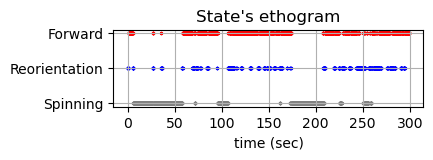

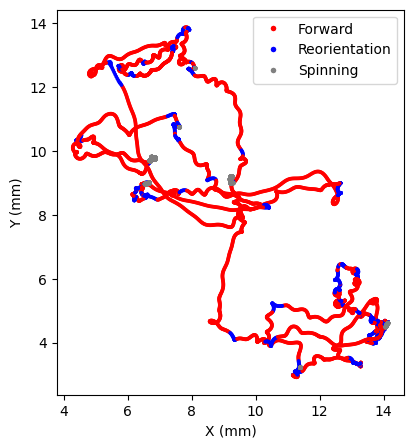

In [ ]:
### Plotting of ethogram and colorcoded trajectory
plt.figure(figsize = (4,1))
plt.scatter(time_axis_sec_with_0, states_forward_nan, color="red", s=2)
plt.scatter(time_axis_sec_with_0, states_spinning_nan, color = "gray", s=2)
plt.scatter(time_axis_sec_with_0, states_reorient_nan, color = "blue", s=2)
plt.title("State's ethogram")
plt.xlabel("time (sec)")
plt.yticks([0, 1, 2], ["Spinning", "Reorientation", "Forward"])
plt.grid(True)
plt.show()

state_cmap = ListedColormap(["gray", "blue", "red"])
plt.figure(figsize=(5,5))
plt.scatter(translations_to_analyze[:,0], translations_to_analyze[:,1], c= states, cmap=state_cmap, s=3)
plt.scatter(translations_to_analyze[:,0], translations_to_analyze[:,1], c= states_spinning_nan, cmap=state_cmap, s=5)
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.grid(False)
plt.gca().set_aspect('equal', adjustable='box')
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="red", markersize=5, label="Forward"),  # Orange marker
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=5, label="Reorientation"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor="gray", markersize=5, label="Spinning")]   # Blue marker with alpha
plt.legend(handles=legend_elements)
plt.show()

### Saving metrics and state indices

In [ ]:
### Saving time evolution of basic metrics
output_path_csv = os.path.join(output_path ,"trajectory_metrics_window_" + str(target_window_mov_av) + "_sec.csv")

data = {
    "speed_cell_smooth": speed_cell_smooth,
    "ang_velocity_cell_smooth": ang_velocity_cell_smooth,
    "dav_array": dav_array,
    "msd_values": msd_values,
}

max_len = max(len(arr) for arr in data.values())
for key in data:
    arr = np.array(data[key])
    if len(arr) < max_len:
        arr = np.pad(arr, (0, max_len - len(arr)), constant_values=np.nan)
    data[key] = arr

df = pd.DataFrame(data)
df.to_csv(output_path_csv , index=False)


### Saving the detected states
data_states = {
    "states": states,
    "time_axis_sec_with_0": time_axis_sec_with_0,
    "states_forward_nan": states_forward_nan,
    "states_spinning_nan": states_spinning_nan,
    "states_reorient_nan": states_reorient_nan
}

df_states = pd.DataFrame(data_states)
df_states.to_csv(output_path + "states_thresh_msd_" + str(threshold_MSD) + "thresh_dav_" + str(threshold_dav) + ".csv", index=False)

### Masking the states

In [13]:
### Masking using nan
time_reorient_nans = np.where(states == 1, time_axis_sec_with_0, np.nan)
time_forward_nans     = np.where(states == 2, time_axis_sec_with_0, np.nan)
time_spinning_nans    = np.where(states == 0, time_axis_sec_with_0, np.nan)

### Find nan indices
nan_mask_spinning = np.isnan(states_spinning_nan)
nan_mask_forward = np.isnan(states_forward_nan)
nan_mask_reorient = np.isnan(states_reorient_nan)

### Find indices of valid data (non-nan)
valid_indices_spinning = np.where(~nan_mask_spinning)[0]
valid_indices_forward = np.where(~nan_mask_forward)[0]
valid_indices_reorient = np.where(~nan_mask_reorient)[0]

### Initiate lists for time, positions and indices for each state:
segments_time_spinning = []
segments_traj_x_spinning = []
segments_traj_y_spinning = []
valid_indices_per_segment_spinning = []

segments_time_forward = []
segments_traj_x_forward = []
segments_traj_y_forward = []
valid_indices_per_segment_forward = []

segments_time_reorient = []
segments_traj_x_reorient = []
segments_traj_y_reorient = []
valid_indices_per_segment_reorient = []
    
### Identify where segments of valid data start and end
if len(valid_indices_forward) == 0:
    print("No forward segments detected!")
else:
    diff_indices_forward = np.diff(valid_indices_forward)
    segment_boundaries_forward = np.where(diff_indices_forward > 1)[0] + 1
    segment_boundaries_forward = np.insert(segment_boundaries_forward, 0, 0)
    segment_boundaries_forward = np.append(segment_boundaries_forward, len(valid_indices_forward))

    for i in range(len(segment_boundaries_forward) - 1):
        start_idx = valid_indices_forward[segment_boundaries_forward[i]]
        end_idx = valid_indices_forward[segment_boundaries_forward[i + 1] - 1]
        segments_time_forward.append(time_forward_nans[start_idx:end_idx + 1])
        segments_traj_x_forward.append(smoothed_translations[:, 0][start_idx:end_idx + 1])
        segments_traj_y_forward.append(smoothed_translations[:, 1][start_idx:end_idx + 1])
        valid_indices_per_segment_forward.append(valid_indices_forward[segment_boundaries_forward[i]:segment_boundaries_forward[i + 1]])
    
if len(valid_indices_spinning) == 0:
    print("No spinning segments detected!")
else:
    diff_indices_spinning = np.diff(valid_indices_spinning)
    segment_boundaries_spinning = np.where(diff_indices_spinning > 1)[0] + 1
    segment_boundaries_spinning = np.insert(segment_boundaries_spinning, 0, 0)
    segment_boundaries_spinning = np.append(segment_boundaries_spinning, len(valid_indices_spinning))

    for i in range(len(segment_boundaries_spinning) - 1):
        start_idx = valid_indices_spinning[segment_boundaries_spinning[i]]
        end_idx = valid_indices_spinning[segment_boundaries_spinning[i + 1] - 1]
        segments_time_spinning.append(time_spinning_nans[start_idx:end_idx + 1])
        segments_traj_x_spinning.append(smoothed_translations[:, 0][start_idx:end_idx + 1])
        segments_traj_y_spinning.append(smoothed_translations[:, 1][start_idx:end_idx + 1])
        valid_indices_per_segment_spinning.append(valid_indices_spinning[segment_boundaries_spinning[i]:segment_boundaries_spinning[i + 1]])
    

if len(valid_indices_reorient) == 0:
    print("No reoreintation segments detected!")
else:
    diff_indices_reorient = np.diff(valid_indices_reorient)
    segment_boundaries_reorient = np.where(diff_indices_reorient > 1)[0] + 1
    segment_boundaries_reorient = np.insert(segment_boundaries_reorient, 0, 0)
    segment_boundaries_reorient = np.append(segment_boundaries_reorient, len(valid_indices_reorient))

    for i in range(len(segment_boundaries_reorient) - 1):
        start_idx = valid_indices_reorient[segment_boundaries_reorient[i]]
        end_idx = valid_indices_reorient[segment_boundaries_reorient[i + 1] - 1]
        segments_time_reorient.append(time_reorient_nans[start_idx:end_idx + 1])
        segments_traj_x_reorient.append(smoothed_translations[:, 0][start_idx:end_idx + 1])
        segments_traj_y_reorient.append(smoothed_translations[:, 1][start_idx:end_idx + 1])
        valid_indices_per_segment_reorient.append(valid_indices_reorient[segment_boundaries_reorient[i]:segment_boundaries_reorient[i + 1]])

In [14]:
### Filtering out short segments (false detections due to noisy peaks)
duration_cut = 0.2 # sec
min_num_points = int(np.ceil(duration_cut * fps))
min_num_points_odd = min_num_points if min_num_points % 2 != 0 else min_num_points + 1

segments_x_forward_filtered = []
segments_y_forward_filtered = []
time_forward_filtered = []
valid_indices_forward_filtered = []  

segments_x_reorient_filtered = []
segments_y_reorient_filtered = []
time_reorient_filtered = []
valid_indices_reorient_filtered = []  

segments_x_spinning_filtered = []
segments_y_spinning_filtered = []
time_spinning_filtered = []
valid_indices_spinning_filtered = []  

### Filtering forward segments
for i in range(len(segments_traj_x_forward)):
    if len(segments_traj_x_forward[i]) >= min_num_points_odd:
        segments_x_forward_filtered.append(segments_traj_x_forward[i])
        segments_y_forward_filtered.append(segments_traj_y_forward[i])
        time_forward_filtered.append(segments_time_forward[i])
        valid_indices_forward_filtered.append(valid_indices_per_segment_forward[i])  

### Filtering reorienting segments
for i in range(len(segments_traj_x_reorient)):
    if len(segments_traj_x_reorient[i]) >= min_num_points_odd:
        segments_x_reorient_filtered.append(segments_traj_x_reorient[i])
        segments_y_reorient_filtered.append(segments_traj_y_reorient[i])
        time_reorient_filtered.append(segments_time_reorient[i])
        valid_indices_reorient_filtered.append(valid_indices_per_segment_reorient[i])  
        
### Filter spinning segments
for i in range(len(segments_traj_x_spinning)):
    if len(segments_traj_x_spinning[i]) >= min_num_points_odd:
        segments_x_spinning_filtered.append(segments_traj_x_spinning[i])
        segments_y_spinning_filtered.append(segments_traj_y_spinning[i])
        time_spinning_filtered.append(segments_time_spinning[i])
        valid_indices_spinning_filtered.append(valid_indices_per_segment_spinning[i]) 

### Velocity map

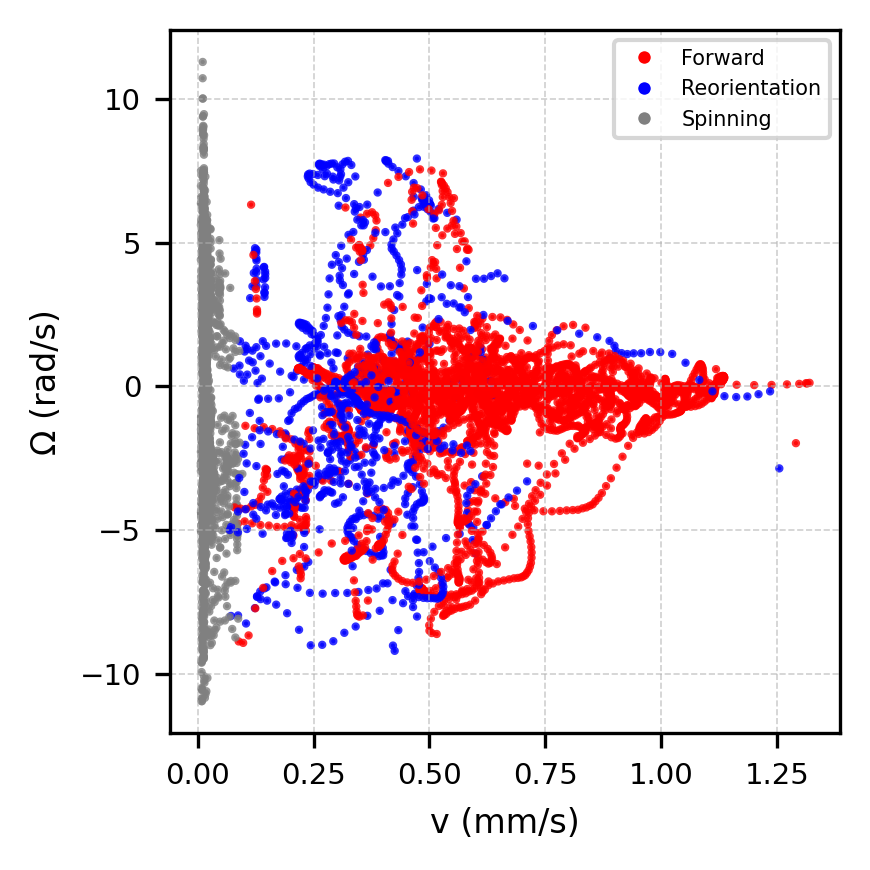

In [ ]:
### Defining colors
color_spinning = 'gray'
color_reorient = 'blue'   
color_forward  = 'red'     

colors = np.full(len(speed_cell_smooth[:-1]), 'k')  # Default
valid_indices_spinning_filtered_flat = np.concatenate(valid_indices_spinning_filtered).flatten()
valid_indices_reorient_filtered_flat = np.concatenate(valid_indices_reorient_filtered).flatten()
valid_indices_forward_filtered_flat = np.concatenate(valid_indices_forward_filtered).flatten()

colors = []
for i in range(len(speed_cell_smooth[:-1])):
    if i in valid_indices_spinning_filtered_flat:
        colors.append(color_spinning)
    elif i in valid_indices_reorient_filtered_flat:
        colors.append(color_reorient)
    elif i in valid_indices_forward_filtered_flat:
        colors.append(color_forward)
    else:
        colors.append('k')
colors = np.array(colors)

### Plotting a scatterplot of Ω vs U
plt.figure(dpi=300, figsize=(3, 3))
### Optional: plot only a subset for quick visualization
N = 7000
subset_indices = np.arange(min(N, len(speed_cell_smooth[:-1])))

# Filter out 'k' points (corresponding to short segments with false detections due to noisy peaks)
subset_colors = colors[subset_indices]
classified_mask = subset_colors != 'k'

plt.scatter(
    speed_cell_smooth[:-1][subset_indices][classified_mask], 
    ang_velocity_cell_smooth[subset_indices][classified_mask], 
    c=subset_colors[classified_mask], 
    s=1, 
    alpha=0.8
)

### Customizing Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Forward', markerfacecolor=color_forward, markersize=4),
    Line2D([0], [0], marker='o', color='w', label='Reorientation', markerfacecolor=color_reorient, markersize=4),
    Line2D([0], [0], marker='o', color='w', label='Spinning', markerfacecolor=color_spinning, markersize=4),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=5)

plt.xlabel('v (mm/s)', fontsize=8)
plt.ylabel('\u03A9 (rad/s)', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
### Saving the relevant arrays to be processed for generating the velocity density map for all trajectories
np.savez(output_path + "scatter_data_velocity_map.npz",
    speed=speed_cell_smooth.to_numpy(),
    ang_velocity=ang_velocity_cell_smooth.to_numpy(),
    spinning_indices=np.concatenate(valid_indices_spinning_filtered),
    reorient_indices=np.concatenate(valid_indices_reorient_filtered),
    forward_indices=np.concatenate(valid_indices_forward_filtered),
)

### Time statistics

In [19]:
### State duration:
durations_forwards = []
durations_spinning = []
durations_reorient = []

for segment in segments_x_forward_filtered:
    num_points = len(segment)
    duration_forwards = num_points / fps
    durations_forwards.append(duration_forwards)
    
for segment in segments_x_spinning_filtered:
    num_points = len(segment)
    duration_spinning = num_points / fps
    durations_spinning.append(duration_spinning)

for segment in segments_x_reorient_filtered:
    num_points = len(segment)
    duration_reorient = num_points / fps
    durations_reorient.append(duration_reorient)
    

In [20]:
# Number of segments:
num_segments_forward   = len(segments_x_forward_filtered)
num_segments_reorient = len(segments_x_reorient_filtered)
num_segments_spinning = len(segments_x_spinning_filtered)

total_num_segments = num_segments_forward + num_segments_reorient + num_segments_spinning


perc_segments_forward   = num_segments_forward / total_num_segments
perc_segments_reorient = num_segments_reorient / total_num_segments
perc_segments_spinning  = num_segments_spinning / total_num_segments

In [ ]:
### Saving the time statistics to be used for the calculation of the survival probability of all segments
data_segments = {
    "durations_reorient": durations_reorient,
    "durations_forwards": durations_forwards,
    "durations_spinning": durations_spinning,
    "num_segments_forward": num_segments_forward,
    "num_segments_reorient": num_segments_reorient,
    "num_segments_spinning": num_segments_spinning,
    "perc_segments_forward": perc_segments_forward,
    "perc_segments_reorient": perc_segments_reorient,
    "perc_segments_spinning": perc_segments_spinning,
}

# Find max length
max_len = max(len(arr) if hasattr(arr, '__len__') else 1 for arr in data_segments.values())

# Pad arrays with NaN
for key, arr in data_segments.items():
    if hasattr(arr, '__len__') and len(arr) < max_len:
        # Convert to numpy array and pad
        arr_np = np.array(arr, dtype=float)  # float type to hold NaNs
        pad_width = max_len - len(arr_np)
        arr_np = np.pad(arr_np, (0, pad_width), constant_values=np.nan)
        data_segments[key] = arr_np
    elif not hasattr(arr, '__len__'):
        # If scalar, convert to list and pad
        data_segments[key] = np.array([arr] + [np.nan]*(max_len-1))

# Convert to DataFrame
df_segments = pd.DataFrame(data_segments)

# Save to CSV
df_segments.to_csv(output_path + "time_statistics_thresh_msd_" + str(threshold_MSD) + "thresh_dav_" + str(threshold_dav) + ".csv", index=False)